In [ ]:
from google.colab import userdata

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          19044        418                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1550         44                1  
maulikgajera/esports-world-cup-2025-dataset                         Esports World Cup 2025 Dataset                           20722  2026-05-02 17:17:36.950000            387         23

In [ ]:
!kaggle datasets download -d sauravagarwal/flower-classification

Dataset URL: https://www.kaggle.com/datasets/sauravagarwal/flower-classification
License(s): CC0-1.0
100% 219M/219M [00:02<00:00, 99.5MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("flower-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/flowers_dataset")

print("Done!")

Done!


In [ ]:
import os

for root, dirs, files in os.walk("/content/flowers_dataset"):
    print(f"📂 {root}")
    print(f"   Folders: {dirs}")
    print(f"   Files: {len(files)}")
    print("-"*40)

📂 /content/flowers_dataset
   Folders: ['flowers']
   Files: 0
----------------------------------------
📂 /content/flowers_dataset/flowers
   Folders: ['flowers']
   Files: 0
----------------------------------------
📂 /content/flowers_dataset/flowers/flowers
   Folders: ['flower_photos']
   Files: 0
----------------------------------------
📂 /content/flowers_dataset/flowers/flowers/flower_photos
   Folders: ['test', 'train', 'validation']
   Files: 0
----------------------------------------
📂 /content/flowers_dataset/flowers/flowers/flower_photos/test
   Folders: ['tulips', 'dandelion', 'roses', 'sunflowers', 'daisy']
   Files: 0
----------------------------------------
📂 /content/flowers_dataset/flowers/flowers/flower_photos/test/tulips
   Folders: []
   Files: 10
----------------------------------------
📂 /content/flowers_dataset/flowers/flowers/flower_photos/test/dandelion
   Folders: []
   Files: 10
----------------------------------------
📂 /content/flowers_dataset/flowers/flowers

In [ ]:
BASE_PATH = "/content/flowers_dataset/flowers/flowers/flower_photos"

train_path = BASE_PATH + "/train"
val_path   = BASE_PATH + "/validation"
test_path  = BASE_PATH + "/test"

In [ ]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 3540 files belonging to 5 classes.
Found 80 files belonging to 5 classes.
Found 50 files belonging to 5 classes.


In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
def normalize(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(normalize)
val_ds   = val_ds.map(normalize)
test_ds  = test_ds.map(normalize)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 128

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')  # 5 flower classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,717 (9.26 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.7381 - loss: 0.8009 - val_accuracy: 0.8750 - val_loss: 0.4444
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 76s 371ms/step - accuracy: 0.8780 - loss: 0.3637 - val_accuracy: 0.9125 - val_loss: 0.3491
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 44s 393ms/step - accuracy: 0.9203 - loss: 0.2277 - val_accuracy: 0.9000 - val_loss: 0.4253
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 58s 523ms/step - accuracy: 0.9381 - loss: 0.1670 - val_accuracy: 0.8875 - val_loss: 0.4388
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 43s 390ms/step - accuracy: 0.9582 - loss: 0.1174 - val_accuracy: 0.9000 - val_loss: 0.4480


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.8600 - loss: 0.8704
Test Accuracy: 0.8600000143051147


In [ ]:
from tensorflow.keras import Model

# Get last conv layer
last_conv_layer = base_model.get_layer(last_conv_layer_name)

# Get model layers after base_model
x = base_model.output
x = model.layers[1](x)   # GlobalAveragePooling
x = model.layers[2](x)   # BatchNorm
x = model.layers[3](x)   # Dense
x = model.layers[4](x)   # Dropout
output = model.layers[5](x)  # Final Dense

# Build functional model
grad_model = Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, output]
)

In [ ]:
import tensorflow as tf
import numpy as np

def get_gradcam_heatmap(img_array, grad_model):

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [ ]:
heatmap = get_gradcam_heatmap(img_array, grad_model)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def display_gradcam(img, heatmap, alpha=0.4):

    # Convert tensor → numpy
    if hasattr(img, "numpy"):
        img = img.numpy()

    # Normalize image (in case already scaled)
    img = img - img.min()
    img = img / (img.max() + 1e-8)

    # Convert heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Resize heatmap to match image
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Apply color map
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on image
    superimposed_img = heatmap * alpha + img * 255
    superimposed_img = np.uint8(superimposed_img)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Overlay")
    plt.axis('off')

    plt.show()

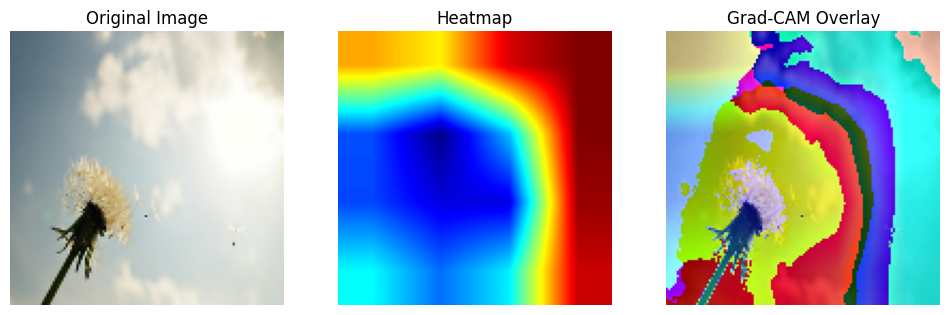

In [ ]:
display_gradcam(img, heatmap)